<a href="https://colab.research.google.com/github/Aditi-dev07/Cisco_DataScience_Projects/blob/main/Data%20Visualization/Longest%20divers/longest-diving-animals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Ocean's Longest Diving Animals

How long can air-breathing animals hold their breath while diving? Which animals can stay submerged for the longest time?

The file `longest-diving-animals.csv` contains the recorded durations, in minutes, of the longest dives ever recorded in the scientific literature for different species of marine mammals.

In [1]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'longest-diving-animals.csv'.

from google.colab import files
uploaded = files.upload()

Saving longest-diving-animals.csv to longest-diving-animals (1).csv


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('longest-diving-animals.csv')
df.head()

,animal,category,duration
0,Emperor Penguin,penguins,32.2
1,King Penguin,penguins,9.2
2,Rockhopper Penguin,penguins,3.2
3,Macaroni Penguin,penguins,6.3
4,Royal Penguin,penguins,7.5


### Project Ideas

- Create horizontal bar plots to show the longest diving animals, either for each category or within a category.

- Follow the Pro Tips.

- Convert dive durations from minutes to hours for easier understanding - 2.5 hours is clearer than 150 minutes.

- Add a reference bar to help readers build intuition about the durations.

Side Note: The longest time a person has held their breath underwater is 24 minutes 37 seconds. This was done at the surface of a pool, not while freediving, so it might not directly comparable.


## Horizontal bar plots to show the longest diving animals

In [37]:
df['duration_hr'] = (df['duration'] / 60).round(2)
df.head()

,animal,category,duration,duration_hr
0,Bowhead Whale,baleen whales,48.0,0.80
1,Humpback Whale,baleen whales,24.0,0.40
2,Fin Whale,baleen whales,16.9,0.28
3,Blue Whale,baleen whales,16.1,0.27
4,North Atlantic Right Whale,baleen whales,16.3,0.27


In [38]:
top_5 = df.sort_values('duration_hr', ascending= False)
df.head()

,animal,category,duration,duration_hr
0,Bowhead Whale,baleen whales,48.0,0.80
1,Humpback Whale,baleen whales,24.0,0.40
2,Fin Whale,baleen whales,16.9,0.28
3,Blue Whale,baleen whales,16.1,0.27
4,North Atlantic Right Whale,baleen whales,16.3,0.27


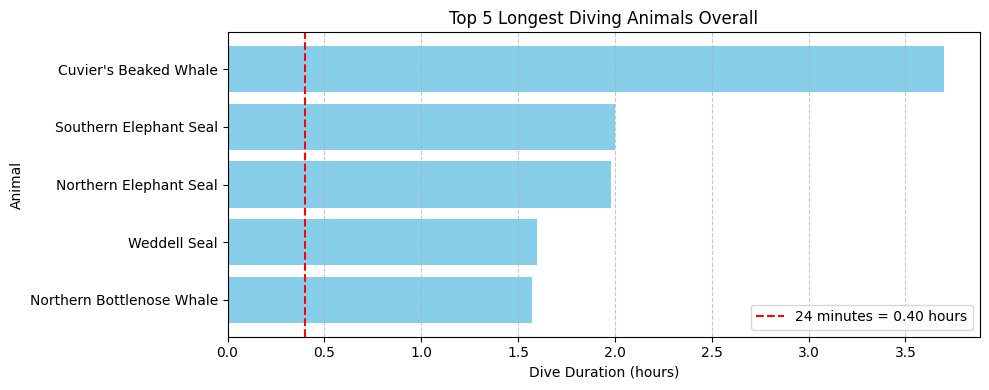

In [39]:
import matplotlib.pyplot as plt

top_5 = df.sort_values('duration_hr', ascending= False).head(5)
df.head()

# Create the horizontal bar plot
plt.figure(figsize=(10, 4))
plt.barh(top_5['animal'], top_5['duration_hr'], color='skyblue')

# Add labels and title
plt.xlabel('Dive Duration (hours)')
plt.ylabel('Animal')
plt.title('Top 5 Longest Diving Animals Overall')

# Add grid for better readability
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.gca().invert_yaxis()

#compare human breath holding to animal
longest_time_human_hold_breadth = 24 / 60
plt.axvline(x=longest_time_human_hold_breadth, color='red', linestyle='--', label=f'24 minutes = {longest_time_human_hold_breadth:.2f} hours')
plt.legend()

plt.tight_layout()
plt.show()

In [40]:
df['category'].value_counts()


,count
category,
other seabirds,40
seals,24
toothed whales,14
penguins,14
baleen whales,7
sea lions,5
other marine mammals,2
turtles,1
walruses,1


##Horizontal bar plots to show the longest diving animals, either for each category

In [41]:
df_grouped = df.loc[df.groupby('category')['duration_hr'].idxmax()].sort_values('duration_hr', ascending=False)
each_category = df_grouped[['category', 'animal', 'duration_hr']].copy()
each_category

,category,animal,duration_hr
92,toothed whales,Cuvier's Beaked Whale,3.70
68,seals,Southern Elephant Seal,2.00
106,turtles,Leatherback Turtle,1.14
107,walruses,Atlantic Walrus,0.82
0,baleen whales,Bowhead Whale,0.80
49,penguins,Emperor Penguin,0.54
7,other marine mammals,Florida Manatee,0.40
63,sea lions,California Sea Lion,0.27
9,other seabirds,Crozet Shag,0.10


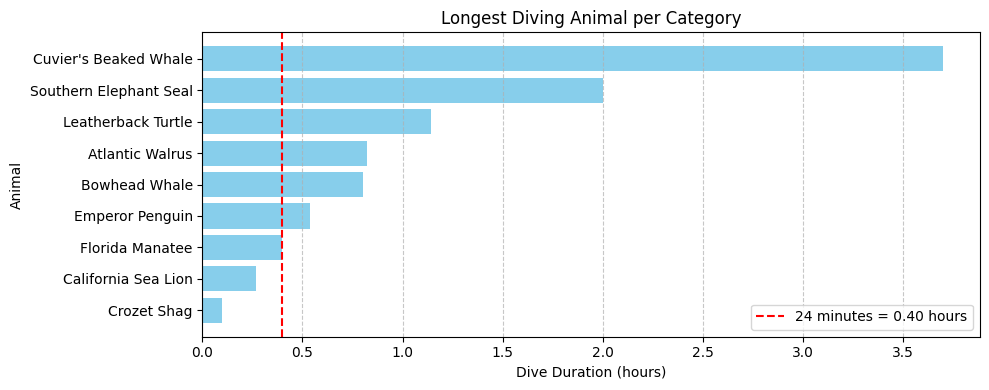

In [42]:
plt.figure(figsize=(10, 4))
plt.barh(each_category['animal'], each_category['duration_hr'], color='skyblue')
plt.xlabel('Dive Duration (hours)')
plt.ylabel('Animal')
plt.title('Longest Diving Animal per Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()

longest_time_human_hold_breadth = 24 / 60
plt.axvline(x=longest_time_human_hold_breadth, color='red', linestyle='--', label=f'24 minutes = {longest_time_human_hold_breadth:.2f} hours')
plt.legend()

plt.tight_layout()
plt.show()

##

##Horizontal bar plots to show the longest diving animals within a category.

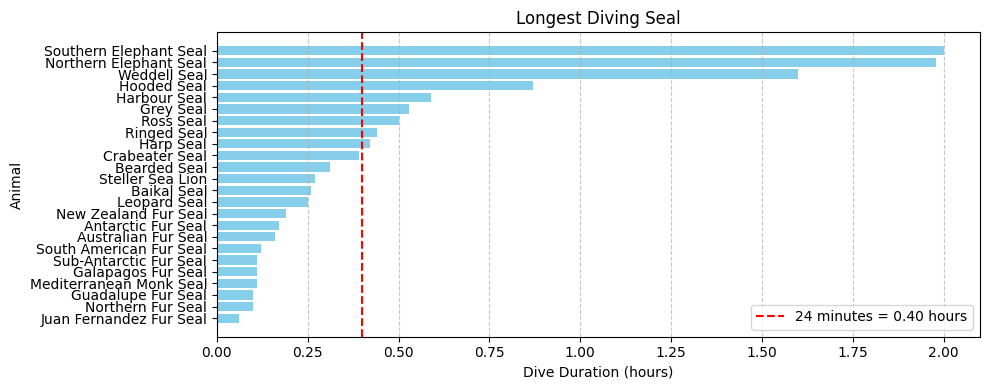

In [43]:
longest_seal_diver = df[df['category'] == 'seals']
plt.figure(figsize=(10, 4))
plt.barh(longest_seal_diver['animal'], longest_seal_diver['duration_hr'], color='skyblue')
plt.xlabel('Dive Duration (hours)')
plt.ylabel('Animal')
plt.title('Longest Diving Seal')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().invert_yaxis()

#compare human breath holding to animal
longest_time_human_hold_breadth = 24 / 60
plt.axvline(x=longest_time_human_hold_breadth, color='red', linestyle='--', label=f'24 minutes = {longest_time_human_hold_breadth:.2f} hours')
plt.legend()

plt.tight_layout()
plt.show()
